# Q1. Supervised Learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


## 1. Data Loading and Inspection 

In [2]:
df = pd.read_csv('q1_heart_disease.csv') #loading the dataset
print("Dataset loaded")

Dataset loaded


In [3]:
#shape of the dataset
print("Shape(rows,columns):", df.shape)

Shape(rows,columns): (800, 12)


In [4]:
#Data types
print("Data Types:")
print(df.dtypes)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object


In [5]:
df.info() #summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    str    
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    str    
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    str    
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 75.1 KB


In [6]:
#Missing values
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [7]:
# First five rows of the dataset
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2.Exploratory Data Analysis

In [8]:
# Figure 1. Target Class Distribution Plot
print(df['heart_disease'].value_counts()) #count of each class in the target variable
# 0 = No Disease, 1 = Disease

heart_disease
1    407
0    393
Name: count, dtype: int64


### Chart 1

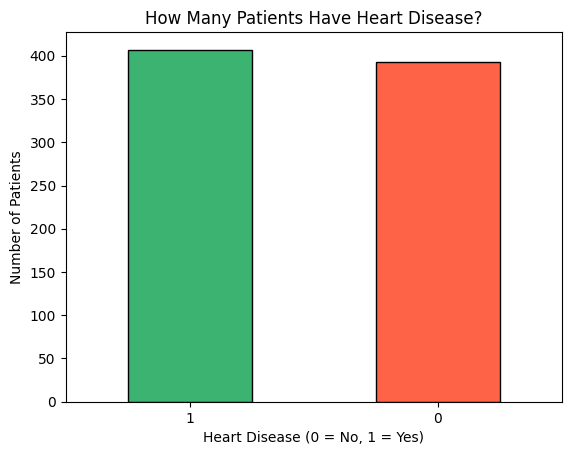

In [9]:
#bar plot of target class distribution
df['heart_disease'].value_counts().plot(kind='bar', color=['mediumseagreen', 'tomato'], edgecolor='black')

plt.title('How Many Patients Have Heart Disease?')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

It can be observed from the chart that 393 patients have no heart disease while 407 suffer from it. The two bars are nearly the same height which shows that the classes are **balanced** ( approximately 49% and 51%). Hence the model will get roughly equal examples of both groups to learn from.

### Chart 2

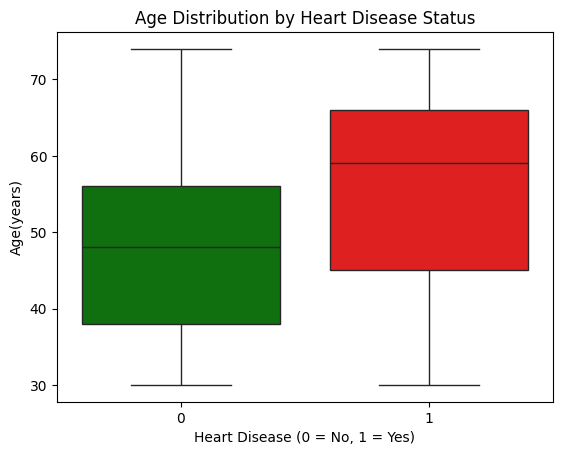

Average Age by Heart Disease Status:
heart_disease
0    48.4
1    55.8
Name: age, dtype: float64


In [10]:
sns.boxplot(x='heart_disease', y='age', data=df, palette=['green', 'red'])
plt.title('Age Distribution by Heart Disease Status')   
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age(years)')
plt.show()

#Print average age for each group
avg_age = df.groupby('heart_disease')['age'].mean().round(1) 
print("Average Age by Heart Disease Status:")
print(avg_age)

- It can be observed from the box plot that the patients with heart disease tend to be slightly older. 
- But since there is a lot of overlap age alone cannot diagnose heart disease. The model will need all the features together to reach the conclusion.

### Chart 3 - Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

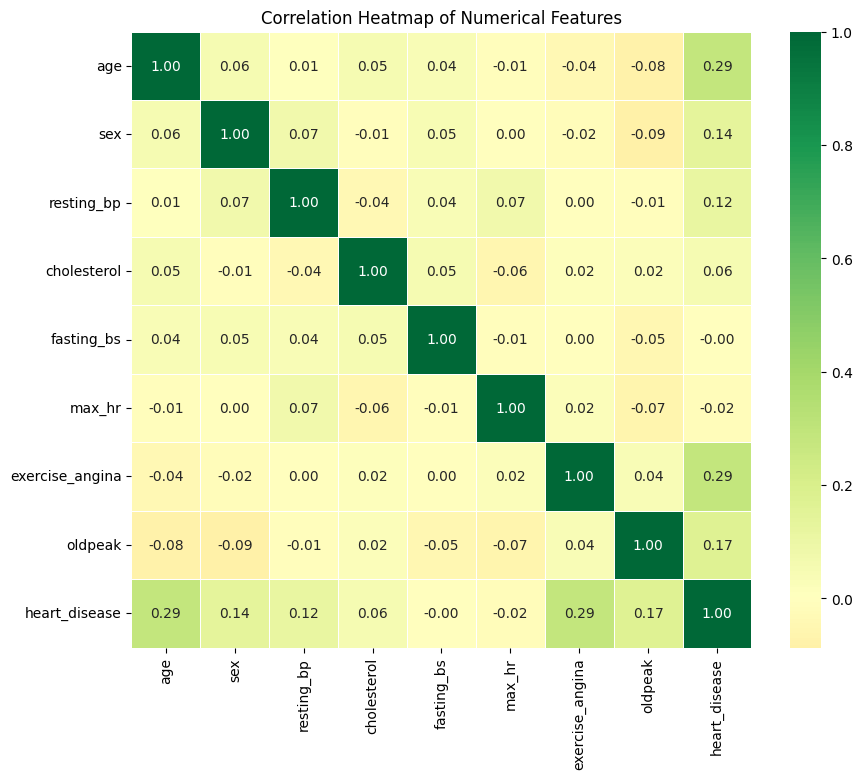

In [11]:
# Correlation Heatmap
#selecting only numeric columns for correlation
num_cols = ['age','sex','resting_bp','cholesterol','fasting_bs','max_hr','exercise_angina','oldpeak','heart_disease']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5,center=0)
plt.title('Correlation Heatmap of Numerical Features')


#### Interpretation

**Observing the `heart_disease` row/column:**

- `oldpeak` (ST depression) and  `exercise_angina` (chest pain during exercise) has a **positive correlation** 
- `max_hr` (maximum heart rate) has a **negative correlation** [lower max heart rate associates with heart disease]
- `cholesterol` and `resting_bp` have **weaker correlations** [They matter but less so in isolation}

 We don't see extreme multicollinearity here.

## 3. Data Preprocessing

### Filling missing values

- STRATEGY CHOSEN : Median Imputation
- `resting_bp` and `cholesterol` have blank cells which  can be filled using **median** of those columns.
- The median being the middle value as compared to mean is not affected by extremes or outliers so it is a safer choice for medical measurements. 
 - We are not dropping rows because dropping 56 rows out of 800(7%) wastes data and also may introduce bias if the missing rows aren't random.

In [12]:
# creating a copy
df_clean = df.copy()

#filling missing values with median
df_clean['resting_bp']  = df_clean['resting_bp'].fillna(df_clean['resting_bp'].median())
df_clean['cholesterol'] = df_clean['cholesterol'].fillna(df_clean['cholesterol'].median())

print("Missing values remaining:")
print(df_clean.isnull().sum())


Missing values remaining:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [13]:
#Separating features and target variable
X = df_clean.drop(columns=['heart_disease'])   # All columns Expect the target variable
y = df_clean['heart_disease']   # Target variable

print("X shape:", X.shape)  
print("y shape:", y.shape) 

X shape: (800, 11)
y shape: (800,)


### One-Hot Coding

In [14]:
#one-hot encoding for categorical variables
X_encoded = pd.get_dummies(X, drop_first=True) #dropping first column to avoid dummy variable trap

print("Columns before encoding:", X.shape[1])
print("Columns after encoding: ", X_encoded.shape[1])

print(f"\nNew column names:")
print(X_encoded.columns.tolist())

Columns before encoding: 11
Columns after encoding:  15

New column names:
['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up']


### Train-Test Split

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f"Training set: {X_train.shape[0]} patients ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} patients ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")

Training set: 640 patients (80%)
Test set: 160 patients (20%)


### Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # learning and transforming the training data
X_test_scaled = scaler.transform(X_test) # only transforming the test data
print("Scaling complete!")

Scaling complete!


## 4.Model Training

In [17]:
#Creating the models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

In [18]:
#Training the models
dt_model.fit(X_train_scaled, y_train)
print("Decision Tree trained!")

rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained!")

gb_model.fit(X_train_scaled, y_train)
print("Gradient Boosting trained!")

Decision Tree trained!
Random Forest trained!
Gradient Boosting trained!


## 5.Model Evaluation 

MODEL 1: DECISION TREE


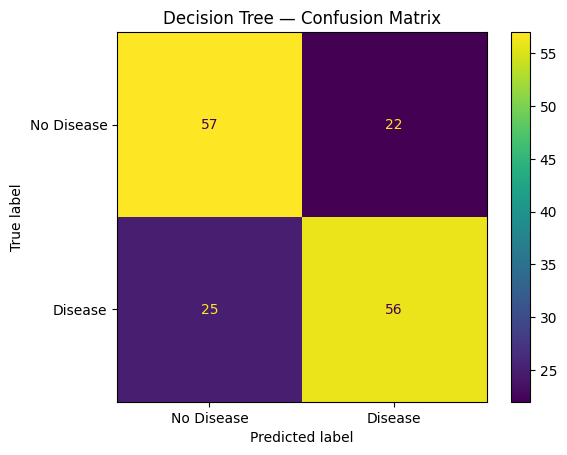

              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



In [20]:
print("MODEL 1: DECISION TREE")
print("=" * 50)
y_pred_dt = dt_model.predict(X_test_scaled)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['No Disease', 'Disease'])
plt.title('Decision Tree — Confusion Matrix')
plt.show()

# Precision, Recall, F1
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

MODEL 2: RANDOM FOREST


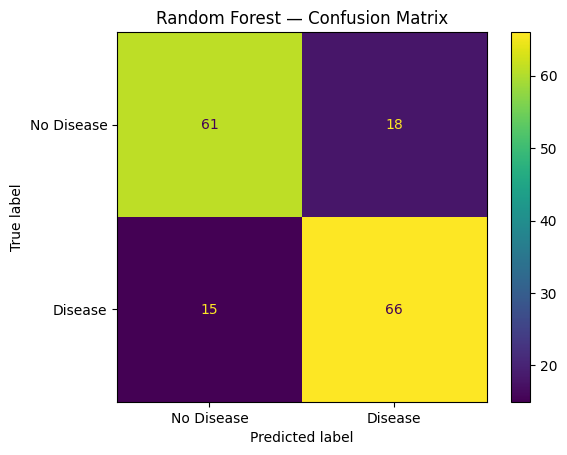

              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [21]:
# Model 2: Random Forest 
print("MODEL 2: RANDOM FOREST")
print("=" * 50)

y_pred_rf = rf_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No Disease', 'Disease'])
plt.title('Random Forest — Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

MODEL 3: GRADIENT BOOSTING


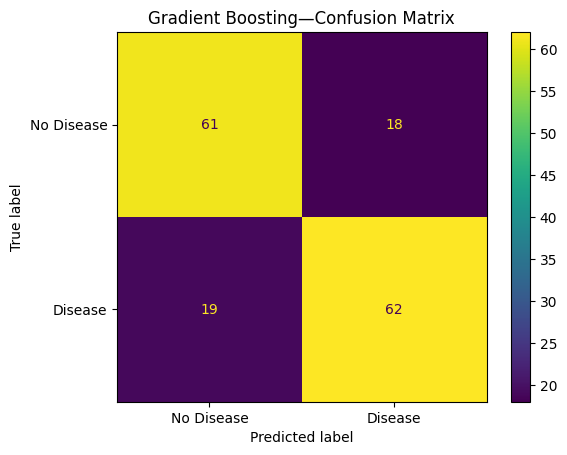

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [24]:
# Model 3: Gradient Boosting
print("MODEL 3: GRADIENT BOOSTING")
print("=" * 50)

y_pred_gb = gb_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, display_labels=['No Disease', 'Disease'])
plt.title('Gradient Boosting—Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Disease']))

In [26]:
# Summary comparison table
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)

for name, y_pred in [('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]:
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{name:<22} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

Model                    Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
Decision Tree               0.706      0.718      0.691      0.704
Random Forest               0.794      0.786      0.815      0.800
Gradient Boosting           0.769      0.775      0.765      0.770


#### Model which performs the best
In a medical context, both false negatives(missing disease) and false positives(false alarm) have consequences.**F1-Score** balances both precision and recall, making it the most appropriate single metric when both errors matter.

- Hence looking at the F1 score -
 
  **Random Forest** is the best performing model(0.800- F1 score as compared to 0.704 and 0.770 of Decision tree and Gradient Boosting).
  
   - As compared to a single Decision Tree averaging many trees cancels out the errors of individual trees.
   - Random forest is also robust to noise and outliers.
  
  At a larger amount of dataset Gradient Boosting may prove to be the best.

## 6.Hyperparameter Tuning

In [27]:
# Defining which values to try
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 5, 10],   
    'max_features': ['sqrt', 'log2']  
}
print("Total combinations to try:", 3 * 3 * 2)

Total combinations to try: 18


In [28]:
# Running the search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest settings found:")
print(grid_search.best_params_)
print("\nBest F1 score during cross-validation:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best settings found:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}

Best F1 score during cross-validation: 0.8197


In [29]:
# Evaluating the tuned model on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("TUNED RANDOM FOREST — Test Results:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

TUNED RANDOM FOREST — Test Results:
              precision    recall  f1-score   support

  No Disease       0.78      0.75      0.76        79
     Disease       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [ ]:
# Comparing baseline Random Forest vs tuned Random Forest
print(f"{'Metric':<12} {'Baseline RF':>12} {'Tuned RF':>10} {'Change':>10}")
print("-" * 48)

metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_tuned)],
    'Recall':    [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_tuned)],
    'F1-Score':  [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred_tuned)]
}

for name, (base, tuned) in metrics.items():
    change = tuned - base
    arrow = 'UP' if change > 0.0001 else ('DOWN' if change < -0.0001 else 'SAME')
    print(f"{name:<12} {base:>12.4f} {tuned:>10.4f} {arrow:>10}")

Metric        Baseline RF   Tuned RF     Change
------------------------------------------------
Accuracy           0.7937     0.7688       DOWN
Precision          0.7857     0.7619       DOWN
Recall             0.8148     0.7901       DOWN
F1-Score           0.8000     0.7758       DOWN
